In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
df = pd.read_csv("../data/raw/cve_data.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum())

Dataset shape: (2000, 4)

Columns: ['cve_id', 'description', 'cvss_score', 'risk_level']

Data types:
 cve_id          object
description     object
cvss_score     float64
risk_level      object
dtype: object

Null counts:
 cve_id          0
description     0
cvss_score     34
risk_level      0
dtype: int64


In [ ]:
display(df.head(10))
display(df.describe(include="all").T)

,cve_id,description,cvss_score,risk_level
0,CVE-1999-0095,"The debug command in Sendmail is enabled, allo...",10.0,Critical
1,CVE-1999-0082,CWD ~root command in ftpd allows root access.,10.0,Critical
2,CVE-1999-1471,Buffer overflow in passwd in BSD based operati...,7.2,High
3,CVE-1999-1122,Vulnerability in restore in SunOS 4.0.3 and ea...,4.6,Medium
4,CVE-1999-1467,Vulnerability in rcp on SunOS 4.0.x allows rem...,10.0,Critical
5,CVE-1999-1506,"Vulnerability in SMI Sendmail 4.0 and earlier,...",7.5,High
6,CVE-1999-0084,Certain NFS servers allow users to use mknod t...,8.4,High
7,CVE-2000-0388,Buffer overflow in FreeBSD libmytinfo library ...,7.5,High
8,CVE-1999-0209,The SunView (SunTools) selection_svc facility ...,5.0,Medium
9,CVE-1999-1198,BuildDisk program on NeXT systems before 2.0 d...,7.2,High


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cve_id,2000,2000,CVE-2000-0442,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,2000,2000,Qpopper 2.53 and earlier allows local users to...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cvss_score,1966.0,NaN,NaN,NaN,6.274517,2.267565,0.0,5.0,7.2,7.5,10.0
risk_level,2000,5,Medium,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Risk level counts:
 risk_level
Medium      738
High        722
Critical    287
Low         219
Unknown      34
Name: count, dtype: int64

Risk level percentages:
 risk_level
Medium      36.90
High        36.10
Critical    14.35
Low         10.95
Unknown      1.70
Name: proportion, dtype: float64


C:\Users\rashi\AppData\Local\Temp\ipykernel_19972\3723674148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="risk_level", order=df["risk_level"].value_counts().index, palette="viridis")


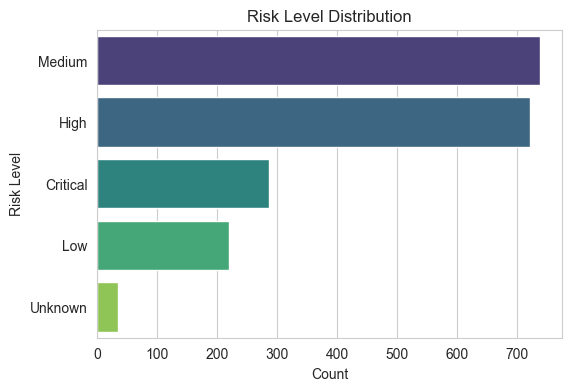

In [ ]:
print("Risk level counts:\n", df["risk_level"].value_counts())
print("\nRisk level percentages:\n", df["risk_level"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, y="risk_level", order=df["risk_level"].value_counts().index, palette="viridis")
plt.title("Risk Level Distribution")
plt.xlabel("Count")
plt.ylabel("Risk Level")
plt.show()

Text length stats:
 count    2000.000000
mean      141.726000
std        66.981962
min        20.000000
25%        95.000000
50%       129.000000
75%       172.000000
max       705.000000
Name: text_len, dtype: float64


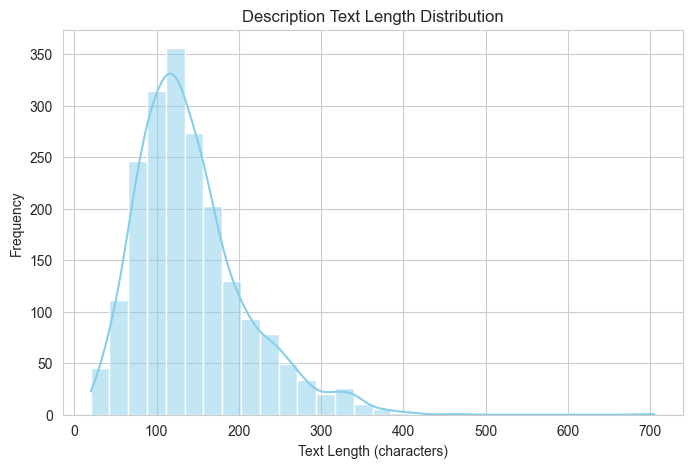

In [ ]:
df["text_len"] = df["description"].astype(str).str.len()

print("Text length stats:\n", df["text_len"].describe())

plt.figure(figsize=(8,5))
sns.histplot(df["text_len"], bins=30, kde=True, color="skyblue")
plt.title("Description Text Length Distribution")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.show()

C:\Users\rashi\AppData\Local\Temp\ipykernel_19972\2149354203.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="coolwarm")


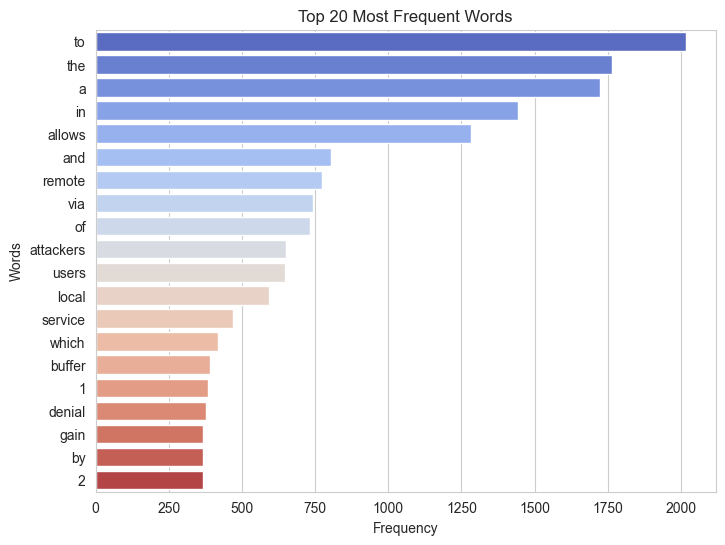

In [ ]:
# Step 5: Top tokens (word frequency)
df["description_clean"] = df["description"].astype(str).str.lower().str.replace(r"https?://\S+", "", regex=True)
df["description_clean"] = df["description_clean"].str.replace(r"[^a-z0-9\s]", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip()

all_words = " ".join(df["description_clean"]).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(8,6))
sns.barplot(x=list(counts), y=list(words), palette="coolwarm")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

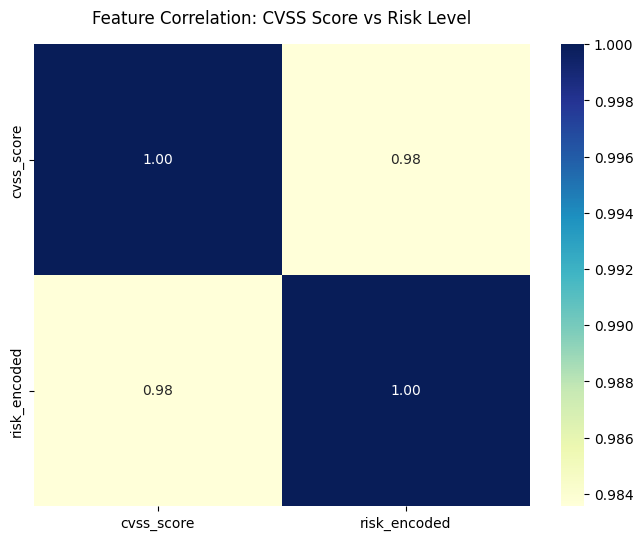

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset load karein
df = pd.read_csv("../data/raw/cve_data.csv")

# 1. Risk Level ko numerical format mein map karein
risk_map = {'None': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df['risk_encoded'] = df['risk_level'].map(risk_map)

# 2. Sirf relevant columns select karein (CVSS aur Encoded Risk)
# Note: Description text hai isliye wo heatmap mein directly nahi aayega
correlation_data = df[['cvss_score', 'risk_encoded']]

# 3. Correlation Matrix aur Heatmap plot karein
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data.corr(), annot=True, cmap='YlGnBu', fmt=".2f")

plt.title('Feature Correlation: CVSS Score vs Risk Level', fontsize=12, pad=15)
plt.savefig('cyberguard_heatmap.png', dpi=300)
plt.show()

In [ ]:
df.isnull().sum()

cve_id                0
description           0
cvss_score           34
risk_level            0
text_len              0
description_clean     0
dtype: int64

In [ ]:
df['cvss_score'] = df['cvss_score'].fillna(df['cvss_score'].mean())

In [ ]:
df.isnull().sum()

cve_id               0
description          0
cvss_score           0
risk_level           0
text_len             0
description_clean    0
dtype: int64

In [ ]:
df.duplicated(subset=['description']).sum()

np.int64(0)

In [ ]:
import re

def basic_text_clean(text):
    text = text.lower()  
    # convert all text to lowercase (SQL → sql)

    text = re.sub(r'[^\w\s]', '', text)  
    # remove punctuation (like !, ., ?, etc.)

    text = re.sub(r'\s+', ' ', text).strip()  
    # remove extra spaces

    return text


df['clean_text'] = df['description'].apply(basic_text_clean)
# apply cleaning to all rows

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()  
    # split sentence into words

    words = [word for word in words if word not in ENGLISH_STOP_WORDS]  
    # remove common words like "the", "is", "and"

    return " ".join(words)  
    # join words back into sentence


df['clean_text'] = df['clean_text'].apply(remove_stopwords)
# apply to cleaned text

In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# --- Step 1: Basic Text Cleaning ---
def basic_text_clean(text):
    text = str(text).lower()  # Lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Punctuation removal
    text = re.sub(r'\s+', ' ', text).strip()  # Extra space removal
    return text

# Original 'description' ko update kar rahe hain
df['description'] = df['description'].apply(basic_text_clean)

# --- Step 2: Stopword Removal ---
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

# Phir se 'description' ko hi update kar rahe hain filtered words ke saath
df['description'] = df['description'].apply(remove_stopwords)

# --- Step 3: Cleanup (Deleting Redundant Columns) ---
# Agar pehle se 'clean_text', 'description_clean' ya 'text_len' bane huye hain, unhe remove karna
cols_to_remove = ['clean_text', 'description_clean', 'text_len']
df.drop(columns=[col for col in cols_to_remove if col in df.columns], inplace=True)

print("✅ Success! The 'description' column is now fully processed and redundant columns removed.")
display(df.head(10))

✅ Success! The 'description' column is now fully processed and redundant columns removed.


,cve_id,description,cvss_score,risk_level,risk_level_encoded
0,CVE-1999-0095,debug command sendmail enabled allowing attack...,10.0,Critical,0
1,CVE-1999-0082,cwd root command ftpd allows root access,10.0,Critical,0
2,CVE-1999-1471,buffer overflow passwd bsd based operating sys...,7.2,High,1
3,CVE-1999-1122,vulnerability restore sunos 403 earlier allows...,4.6,Medium,3
4,CVE-1999-1467,vulnerability rcp sunos 40x allows remote atta...,10.0,Critical,0
5,CVE-1999-1506,vulnerability smi sendmail 40 earlier sunos 40...,7.5,High,1
6,CVE-1999-0084,certain nfs servers allow users use mknod gain...,8.4,High,1
7,CVE-2000-0388,buffer overflow freebsd libmytinfo library all...,7.5,High,1
8,CVE-1999-0209,sunview suntools selection_svc facility allows...,5.0,Medium,3
9,CVE-1999-1198,builddisk program systems 20 does prompt users...,7.2,High,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib
import os

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['risk_level'])

target_path = "../src/models/label_encoder.joblib"
joblib.dump(label_encoder, target_path)

print("✅ Success! LabelEncoder is now fitted and saved in version 1.8.0.")
print("Mapping classes:", label_encoder.classes_)

✅ Success! LabelEncoder is now fitted and saved in version 1.8.0.
Mapping classes: ['Critical' 'High' 'Low' 'Medium' 'Unknown']


In [ ]:
display(df.head(10))
display(df.describe(include="all").T)

,cve_id,description,cvss_score,risk_level,risk_level_encoded
0,CVE-1999-0095,debug command sendmail enabled allowing attack...,10.0,Critical,0
1,CVE-1999-0082,cwd root command ftpd allows root access,10.0,Critical,0
2,CVE-1999-1471,buffer overflow passwd bsd based operating sys...,7.2,High,1
3,CVE-1999-1122,vulnerability restore sunos 403 earlier allows...,4.6,Medium,3
4,CVE-1999-1467,vulnerability rcp sunos 40x allows remote atta...,10.0,Critical,0
5,CVE-1999-1506,vulnerability smi sendmail 40 earlier sunos 40...,7.5,High,1
6,CVE-1999-0084,certain nfs servers allow users use mknod gain...,8.4,High,1
7,CVE-2000-0388,buffer overflow freebsd libmytinfo library all...,7.5,High,1
8,CVE-1999-0209,sunview suntools selection_svc facility allows...,5.0,Medium,3
9,CVE-1999-1198,builddisk program systems 20 does prompt users...,7.2,High,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cve_id,2000,2000,CVE-2000-0442,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,2000,1999,rejected reason use candidate number consultid...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cvss_score,2000.0,NaN,NaN,NaN,6.274517,2.248198,0.0,5.0,7.2,7.5,10.0
risk_level,2000,5,Medium,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
risk_level_encoded,2000.0,NaN,NaN,NaN,1.755,1.145701,0.0,1.0,1.0,3.0,4.0


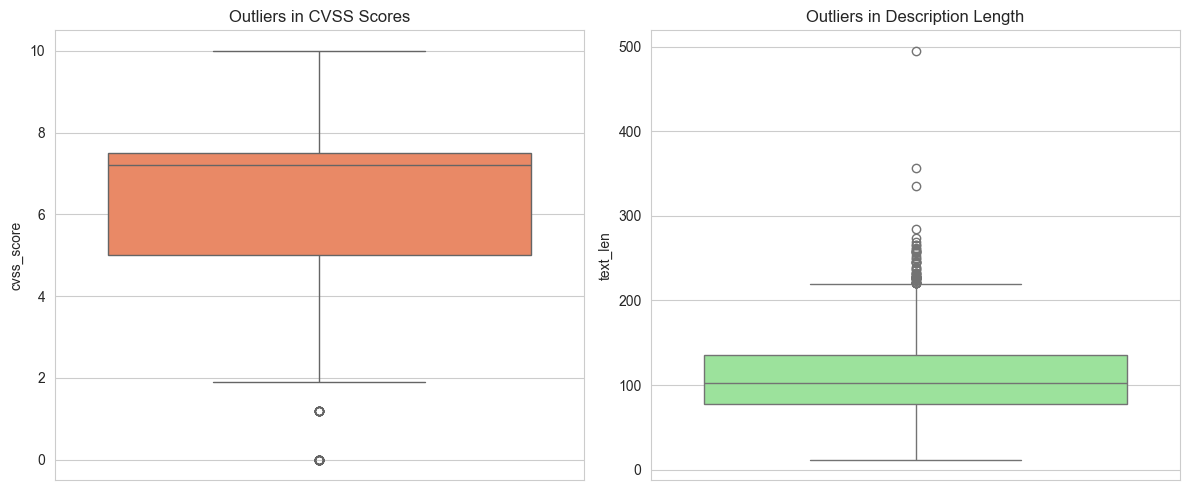

CVSS Outliers: 28
Text Length Outliers: 59


In [40]:
# Pehle text length calculate kar lete hain agar pehle delete kar di ho toh
df['text_len'] = df['description'].apply(len)

plt.figure(figsize=(12, 5))

# Plot 1: CVSS Score Outliers
plt.subplot(1, 2, 1)
sns.boxplot(y=df['cvss_score'], color='coral')
plt.title('Outliers in CVSS Scores')

# Plot 2: Text Length Outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=df['text_len'], color='lightgreen')
plt.title('Outliers in Description Length')

plt.tight_layout()
plt.show()

# Function to calculate outlier count
def get_outlier_count(column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column_name] < (Q1 - 1.5 * IQR)) | (df[column_name] > (Q3 + 1.5 * IQR))]
    return len(outliers)

print(f"CVSS Outliers: {get_outlier_count('cvss_score')}")
print(f"Text Length Outliers: {get_outlier_count('text_len')}")

# Model Training and Comparison
This section trains 4 models (Logistic Regression, Random Forest, SVC, Gradient Boosting), compares their metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
# Preprocess and split
X = df["description"]
y = df["risk_level_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words="english", min_df=3, max_df=0.85, max_features=8000)

In [54]:
import pandas as pd

# 1. Hamara X aur y toh wahi hai jo aapne select kiya
# Lekin paper mein dikhane ke liye hum ek temporary dataframe banate hain
# jo ye dikhaye ki Feature Extraction (X) aur Target (y) kaise aligned hain.

training_sample_df = pd.DataFrame({
    'Input Feature (X)': X.values,
    'Target Label (y)': y.values
})

# 2. Shuru ki 5 rows dikhane ke liye
print("📋 Dataset representation after Feature Selection (X and y):")
display(training_sample_df.head())

# 3. Agar aapko check karna hai ki kitne features bane hain (8000 max_features ke baad)
X_vectorized = vectorizer.fit_transform(X)
print(f"\n📊 Feature Extraction complete. Matrix shape: {X_vectorized.shape}")
print(f"Iska matlab: {X_vectorized.shape[0]} rows hain aur {X_vectorized.shape[1]} unique mathematical features (tokens).")

📋 Dataset representation after Feature Selection (X and y):


,Input Feature (X),Target Label (y)
0,debug command sendmail enabled allowing attack...,0
1,cwd root command ftpd allows root access,0
2,buffer overflow passwd bsd based operating sys...,1
3,vulnerability restore sunos 403 earlier allows...,3
4,vulnerability rcp sunos 40x allows remote atta...,0



📊 Feature Extraction complete. Matrix shape: (2000, 2217)
Iska matlab: 2000 rows hain aur 2217 unique mathematical features (tokens).


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "NaiveBayes": MultinomialNB()
}

results = []
trained_pipes = {}

for name, clf in models.items():
    pipe = Pipeline([("tfidf", vectorizer), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    trained_pipes[name] = pipe

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.38      0.49      0.43        72
           1       0.72      0.55      0.62       181
           2       0.49      0.64      0.55        55
           3       0.65      0.67      0.66       184
           4       1.00      1.00      1.00         8

    accuracy                           0.60       500
   macro avg       0.65      0.67      0.65       500
weighted avg       0.62      0.60      0.61       500

=== RandomForest ===
              precision    recall  f1-score   support

           0       0.34      0.17      0.22        72
           1       0.65      0.59      0.62       181
           2       0.65      0.51      0.57        55
           3       0.59      0.81      0.69       184
           4       1.00      1.00      1.00         8

    accuracy                           0.61       500
   macro avg       0.65      0.61      0.62       500
weighted avg       0.59      

In [ ]:
cmp_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
cmp_df

,model,accuracy,precision,recall,f1
1,RandomForest,0.606,0.590865,0.606,0.586350
0,LogisticRegression,0.602,0.624757,0.602,0.606860
2,GradientBoosting,0.600,0.582440,0.600,0.576585
3,NaiveBayes,0.576,0.664116,0.576,0.508633


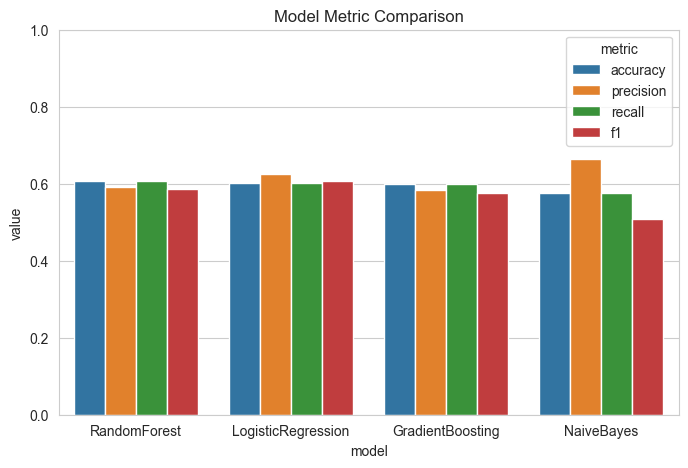

In [ ]:
# Comparison chart
cmp_long = cmp_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1"])
plt.figure(figsize=(8,5))
sns.barplot(data=cmp_long, x="model", y="value", hue="variable")
plt.title("Model Metric Comparison")
plt.ylim(0, 1)
plt.legend(title="metric")
plt.show()

Cross-Validation Implementation

In [52]:
from sklearn.model_selection import cross_validate
import numpy as np
import pandas as pd

# 1. Get the best pipeline from your GridSearch
best_xgb_pipeline = grid_search.best_estimator_

# 2. Perform 5-Fold Cross-Validation
# We use 'stratified' internally to keep the balance of risk levels (0-4) in each fold
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

print("🚀 Starting 5-Fold Cross-Validation for Optimized XGBoost...")

cv_results = cross_validate(
    best_xgb_pipeline, 
    X,           # Raw descriptions
    y,           # Encoded risk levels
    cv=5, 
    scoring=scoring_metrics,
    return_train_score=False
)

# 3. Calculate Mean and Standard Deviation
cv_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Mean Score': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision_weighted'].mean(),
        cv_results['test_recall_weighted'].mean(),
        cv_results['test_f1_weighted'].mean()
    ],
    'Std Deviation (±)': [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision_weighted'].std(),
        cv_results['test_recall_weighted'].std(),
        cv_results['test_f1_weighted'].std()
    ]
})

print("\n✅ Cross-Validation Complete!")
display(cv_df)

🚀 Starting 5-Fold Cross-Validation for Optimized XGBoost...


c:\Users\rashi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rashi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rashi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rashi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:26] WARNING: C:\actio


✅ Cross-Validation Complete!


,Metric,Mean Score,Std Deviation (±)
0,Accuracy,0.573500,0.041067
1,Precision,0.574200,0.054352
2,Recall,0.573500,0.041067
3,F1-Score,0.554355,0.044499


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

def evaluate_all_models(X_test, y_test, models_dict, label_encoder, output_dir="CyberGuard_Evaluation"):
    """
    Comprehensive evaluation for IEEE-standard results.
    Handles both Sklearn Pipelines and Optimized XGBoost.
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    metrics = []
    
    # Binarize labels for ROC curve calculation
    classes = label_encoder.classes_
    n_classes = len(classes)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    plt.figure(figsize=(10, 8))
    
    for name, model in models_dict.items():
        print(f"📊 Evaluating {name}...")
        
        # 1. Prediction Logic (Handling Pipelines & Raw Models)
        try:
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test)
                y_pred = model.predict(X_test)
            else:
                # Fallback for raw XGBoost Boosters
                dmatrix = xgb.DMatrix(X_test)
                y_score = model.predict(dmatrix)
                y_pred = np.argmax(y_score, axis=1)

            # 2. Metrics Calculation
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
            metrics.append({
                'Model': name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })
            
            # 3. Confusion Matrix Plotting
            plt.figure(figsize=(8, 6))
            cm = confusion_matrix(y_test, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=classes, yticklabels=classes)
            plt.title(f'Confusion Matrix - {name}')
            plt.ylabel('Actual Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.savefig(f"{output_dir}/cm_{name}.png")
            plt.close()
            
            # 4. ROC Curve (Micro-averaged for Multiclass)
            if y_score is not None:
                fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
                roc_auc = auc(fpr, tpr)
                plt.figure(1) # Back to the main ROC plot
                plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:0.2f})')
        
        except Exception as e:
            print(f"❌ Error evaluating {name}: {e}")

    # Finalize and Save ROC Plot
    plt.figure(1)
    plt.plot([0, 1], [0, 1], 'k--', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Model Comparison')
    plt.legend(loc="lower right")
    plt.savefig(f"{output_dir}/roc_curves_comparison.png")
    plt.close()
    
    # Save Final Metrics Table
    metrics_df = pd.DataFrame(metrics)
    metrics_df.to_csv(f"{output_dir}/final_comparison_metrics.csv", index=False)
    
    return metrics_df

# --- EXECUTION BLOCK ---

# 1. Prepare your models dictionary
# Make sure 'best_model' is the one you got from GridSearchCV
final_models_dict = {
    "LogisticRegression": trained_pipes.get("LogisticRegression"),
    "RandomForest": trained_pipes.get("RandomForest"),
    "NaiveBayes": trained_pipes.get("NaiveBayes"),
    "Optimized_XGBoost": grid_search.best_estimator_ 
}

# 2. Run Evaluation
# Since we are using Pipelines, X_test should be the raw text descriptions
results_table = evaluate_all_models(
    X_test, 
    y_test, 
    final_models_dict, 
    label_encoder
)

# 3. Display Results
print("\n✅ Evaluation Finished! Check the 'CyberGuard_Evaluation' folder for graphs.")
display(results_table)

📊 Evaluating LogisticRegression...
📊 Evaluating RandomForest...
📊 Evaluating NaiveBayes...
📊 Evaluating Optimized_XGBoost...

✅ Evaluation Finished! Check the 'CyberGuard_Evaluation' folder for graphs.


C:\Users\rashi\AppData\Local\Temp\ipykernel_19972\4103059165.py:82: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--')


,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.602,0.624757,0.602,0.606860
1,RandomForest,0.606,0.590865,0.606,0.586350
2,NaiveBayes,0.576,0.664116,0.576,0.508633
3,Optimized_XGBoost,0.596,0.583946,0.596,0.572276
